In [2]:
import pandas as pd 
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rasterio

In [3]:
gdf = gpd.read_file(r"C:\Users\ohm\Downloads\Sample Data\India State Boundaries\India_District_Boundary.shp")

In [4]:
raster = rasterio.open(r"C:\Users\ohm\Downloads\Sample Data\rasterdata\india.clipped.tif")

In [22]:
gdf.columns

Index(['DISTRICT_L', 'District', 'STATE', 'geometry', 'mean_value',
       'min_value', 'max_value'],
      dtype='object')

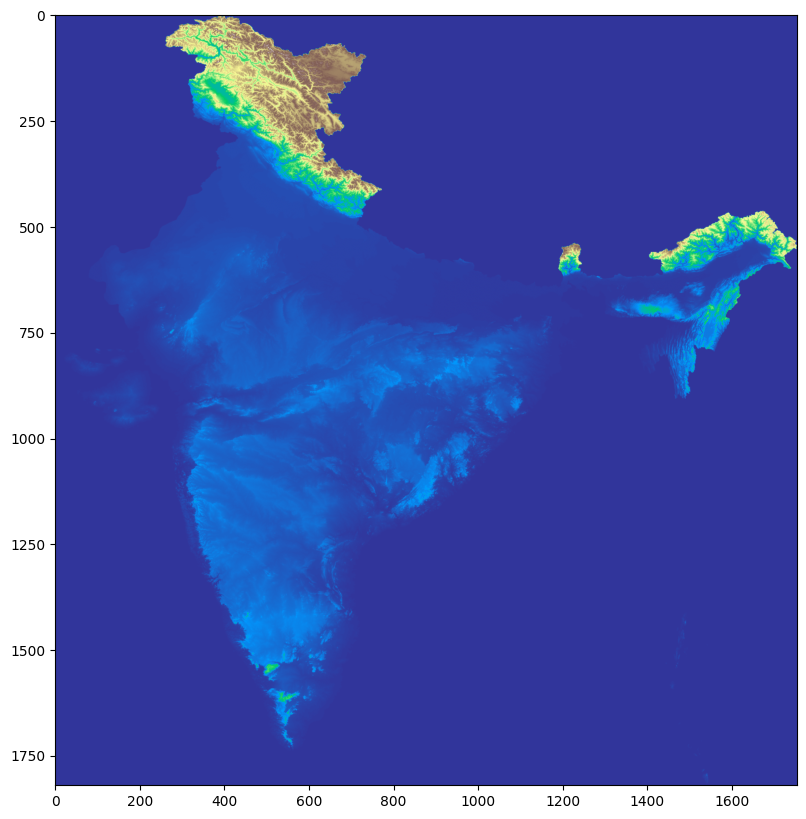

In [5]:
from rasterio.enums import Resampling

band = raster.read(
    1,
    out_shape=(
        raster.height // 20,
        raster.width // 20
    ),
    resampling=Resampling.average
)

plt.figure(figsize=(10,10))
plt.imshow(band, cmap="terrain")
plt.show()

In [6]:
print("Vector CRS:", gdf.crs)
print("Raster CRS:", raster.crs)

Vector CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Raster CRS: EPSG:4326


In [7]:
gdf = gdf.to_crs(raster.crs)

In [8]:
print(gdf.crs)
print(raster.crs)

GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
EPSG:4326


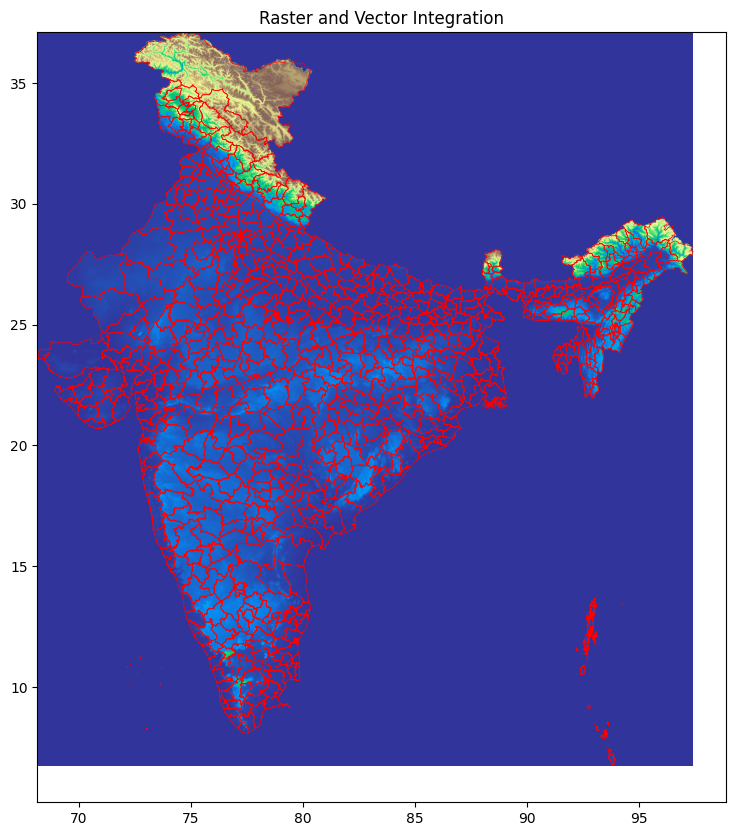

In [9]:
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent

band = raster.read(
    1,
    out_shape=(
        raster.height // 20,
        raster.width // 20
    ),
    resampling=Resampling.average
)
extent = plotting_extent(raster)

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(
    band,
    cmap="terrain",
    extent=extent
)

gdf.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=0.5
)

plt.title("Raster and Vector Integration")
plt.show()

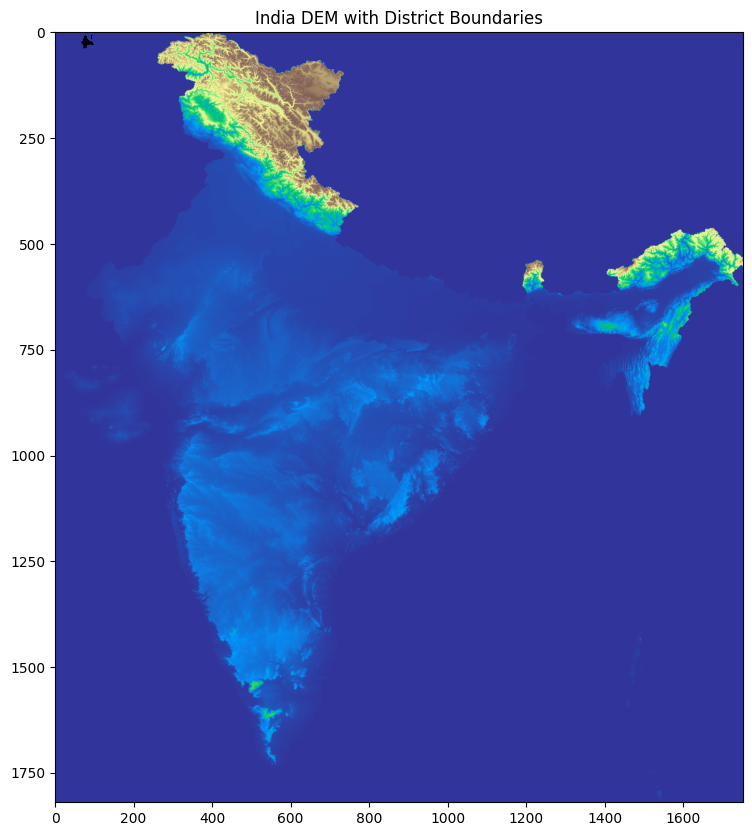

In [10]:
from rasterio.enums import Resampling

band = raster.read(
    1,
    out_shape=(
        raster.height // 20,
        raster.width // 20
    ),
    resampling=Resampling.average
)

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(band, cmap="terrain")

gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("India DEM with District Boundaries")

plt.show()

In [11]:
gdf = gdf.to_crs(raster.crs)

In [12]:
band = raster.read(
    1,
    out_shape=(
        raster.height // 20,
        raster.width // 20
    ),
    resampling=Resampling.average
)

extent = plotting_extent(raster)

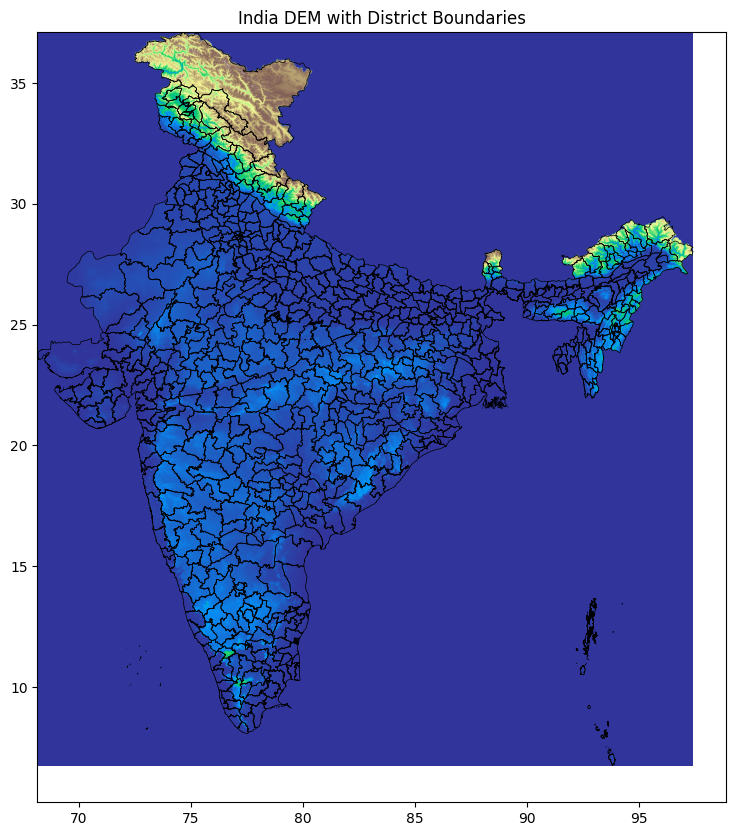

In [13]:
fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(
    band,
    cmap="terrain",
    extent=extent
)

gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

plt.title("India DEM with District Boundaries")
plt.show()

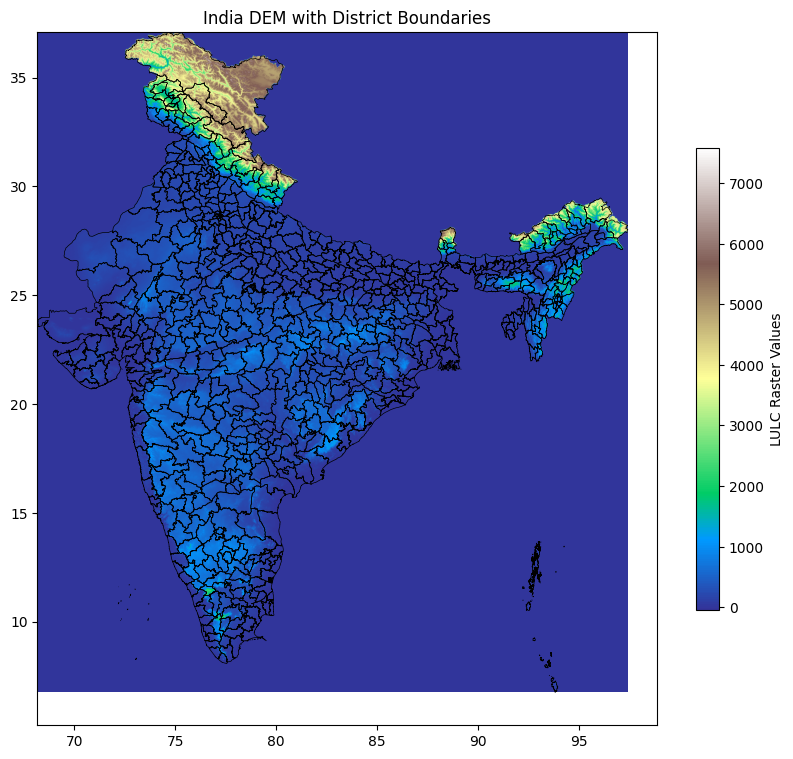

In [14]:
from rasterio.plot import show

band = raster.read(
    1,
    out_shape=(
        raster.height // 20,
        raster.width // 20
    ),
    resampling=Resampling.average
)

extent = plotting_extent(raster)

fig, ax = plt.subplots(figsize=(10,10))

img = ax.imshow(
    band,
    cmap="terrain",
    extent = extent
)


gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

cbar = plt.colorbar(
    img,
    ax=ax,
    shrink = 0.6,
)
cbar.set_label("LULC Raster Values")

plt.title("India DEM with District Boundaries")
plt.show()

In [15]:
!pip install rasterstats

In [16]:
from rasterstats import zonal_stats

In [17]:
stats = zonal_stats(
    gdf,
    r"C:\Users\ohm\Downloads\Sample Data\rasterdata\india.clipped.tif",
    stats=["mean","min","max"],
    nodata = -999
)

In [18]:
print(stats[:5])

[{'min': -15.0, 'max': 241.0, 'mean': 56.18644325657243}, {'min': -8.0, 'max': 81.0, 'mean': 22.765612457683314}, {'min': -6.0, 'max': 66.0, 'mean': 22.530217930236386}, {'min': -10.0, 'max': 611.0, 'mean': 39.722053602599054}, {'min': -10.0, 'max': 343.0, 'mean': 78.30810458269106}]


In [19]:
gdf["mean_value"] = [s["mean"] for s in stats]
gdf["min_value"] = [s["min"] for s in stats]
gdf["max_value"] = [s["max"] for s in stats]

In [23]:
gdf[[
    "District",
    "mean_value",
    "min_value",
    "max_value"
]].head()

,District,mean_value,min_value,max_value
0,MORBI,56.186443,-15.0,241.0
1,AHMADABAD,22.765612,-8.0,81.0
2,ANAND,22.530218,-6.0,66.0
3,DEVBHUMI DWARKA,39.722054,-10.0,611.0
4,JAMNAGAR,78.308105,-10.0,343.0


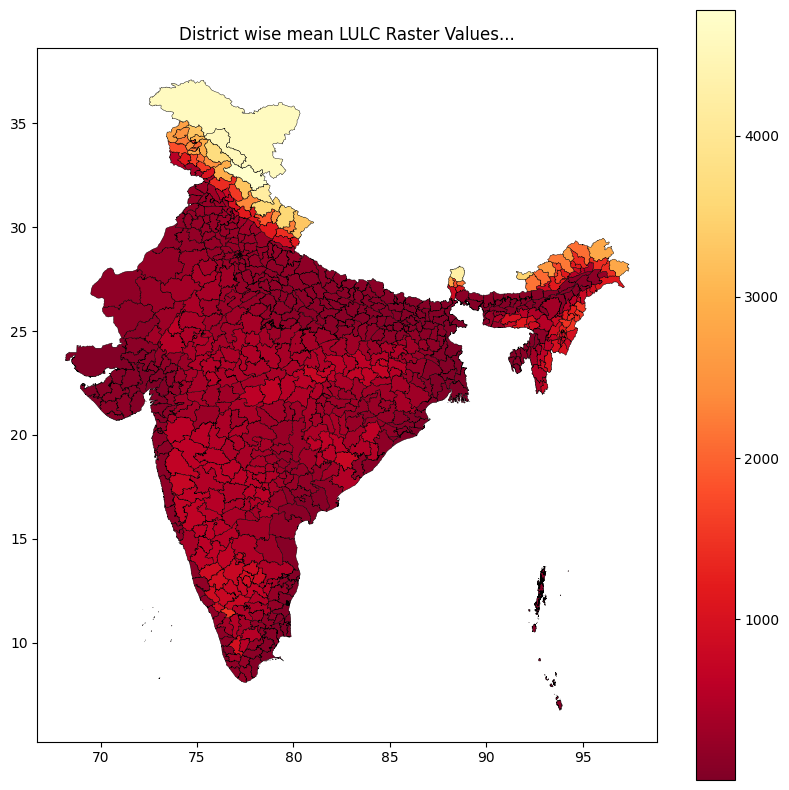

In [26]:
gdf.plot(
    column = "mean_value",
    cmap = "YlOrRd_r",
    legend = True,
    figsize = (10,10),
    edgecolor = "black",
    linewidth = 0.3
)

plt.title("District wise mean LULC Raster Values...")
plt.show()

In [27]:
gdf.to_file("India_District_Boundary.shp")

In [29]:
new_gdf = gpd.read_file("India_District_Boundary.shp")

new_gdf.head()

,DISTRICT_L,District,STATE,mean_value,min_value,max_value,geometry
0,673,MORBI,GUJARAT,56.186443,-15.0,241.0,"POLYGON ((71.1172 23.21252, 71.11778 23.21247,..."
1,438,AHMADABAD,GUJARAT,22.765612,-8.0,81.0,"POLYGON ((71.97206 23.05747, 71.97204 23.05749..."
2,440,ANAND,GUJARAT,22.530218,-6.0,66.0,"POLYGON ((73.02614 22.73478, 73.02693 22.73474..."
3,674,DEVBHUMI DWARKA,GUJARAT,39.722054,-10.0,611.0,"MULTIPOLYGON (((69.33941 22.38597, 69.33976 22..."
4,447,JAMNAGAR,GUJARAT,78.308105,-10.0,343.0,"MULTIPOLYGON (((70.5365 22.40753, 70.53635 22...."


In [30]:
new_gdf.drop(columns = "geometry").to_csv(
    "India_District_Boundary.csv",
    index = False
)

In [31]:
new_gdf[[
    "mean_value",
    "min_value",
    "max_value"
]].describe()

,mean_value,min_value,max_value
count,742.000000,742.000000,742.000000
mean,474.038810,157.237197,1144.196765
std,668.240267,234.468861,1426.043416
min,4.178951,-70.000000,14.000000
25%,125.181283,0.000000,291.500000
50%,254.619737,98.000000,688.500000
75%,511.620928,218.500000,1231.250000
max,4780.075527,2547.000000,8569.000000


In [32]:
new_gdf = gpd.read_file("India_District_Boundary.shp")

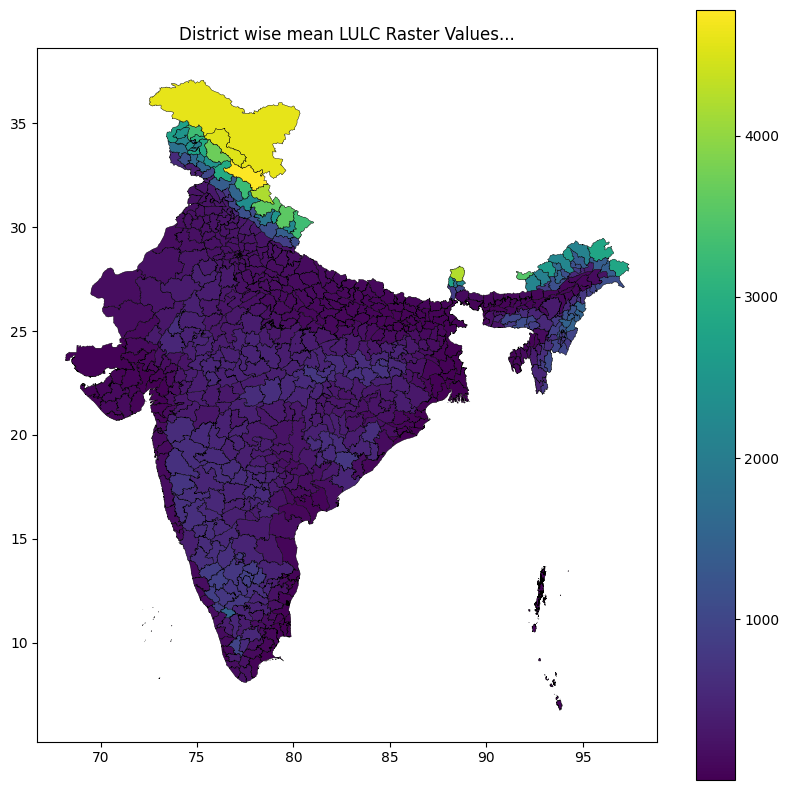

In [33]:
new_gdf.plot(
    column = "mean_value",
    cmap = "viridis",
    legend = True,
    figsize = (10,10),
    edgecolor = "black",
    linewidth = 0.3
)

plt.title("District wise mean LULC Raster Values...")
plt.show()

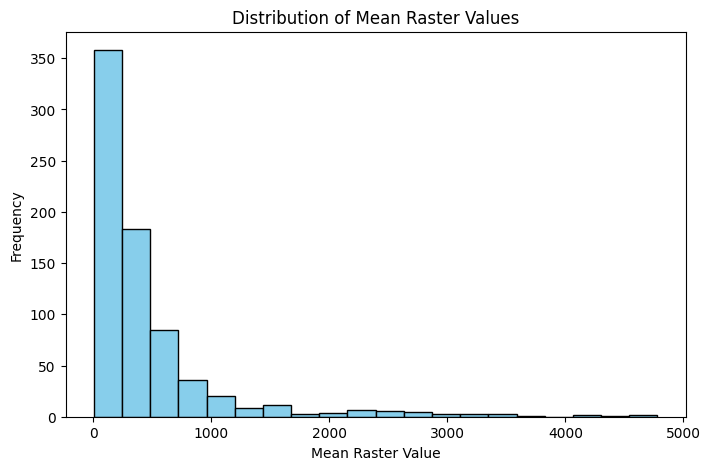

In [35]:
new_gdf["mean_value"].plot(
    kind = "hist",
    bins = 20,
    figsize = (8,5),
    color = "skyblue",
    edgecolor = "black"
)

plt.title("Distribution of Mean Raster Values")

plt.xlabel("Mean Raster Value")

plt.ylabel("Frequency")

plt.show()

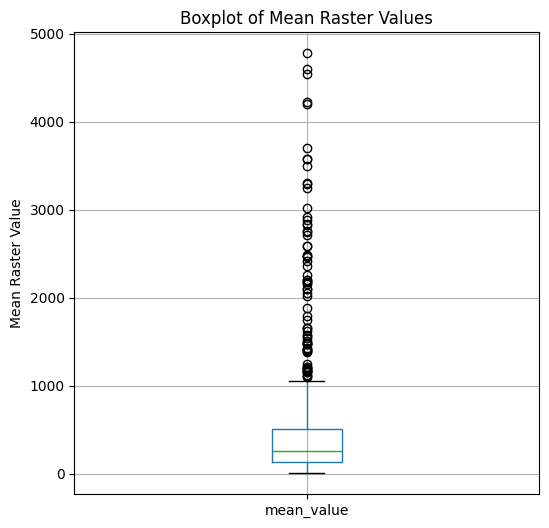

In [36]:
new_gdf.boxplot(
    column = "mean_value",
    figsize = (6,6)
)

plt.title("Boxplot of Mean Raster Values")

plt.ylabel("Mean Raster Value")

plt.show()

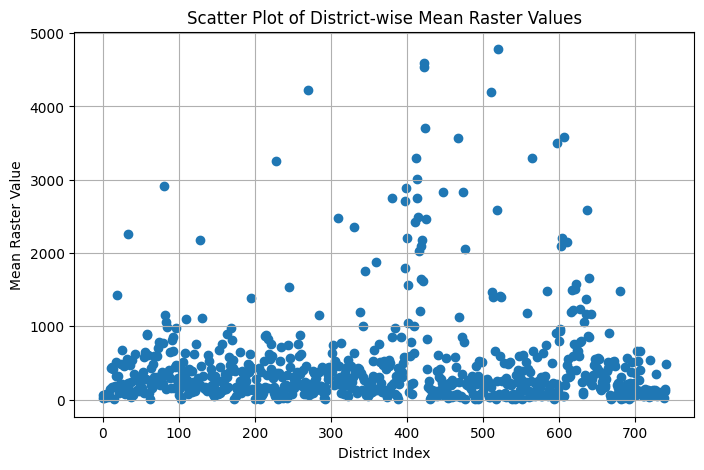

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    new_gdf.index,
    new_gdf["mean_value"]
)

plt.title("Scatter Plot of District-wise Mean Raster Values")

plt.xlabel("District Index")

plt.ylabel("Mean Raster Value")

plt.grid(True)

plt.show()

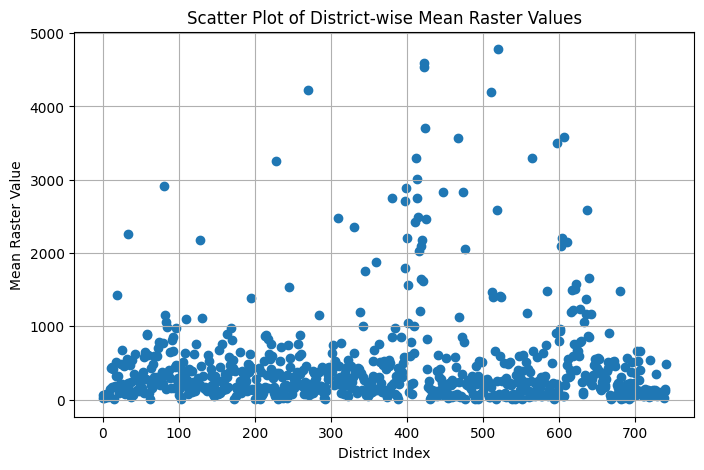

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(
    new_gdf.index,
    new_gdf["mean_value"]
)

plt.title("Scatter Plot of District-wise Mean Raster Values")

plt.xlabel("District Index")

plt.ylabel("Mean Raster Value")

plt.grid(True)

plt.savefig(
    "Scatter_plot_mean_value.png",
    dpi = 300
)

plt.show()

In [39]:
import os
import glob

In [40]:
raster_files = glob.glob(
    r"C:\Users\ohm\Downloads\Sample Data\rasterdata\india.clipped.tif"
)

print(raster_files)

['C:\\Users\\ohm\\Downloads\\Sample Data\\rasterdata\\india.clipped.tif']


In [41]:
for files in raster_files:
    print("Processing Raster:")
    print(files)
    print("------------")

Processing Raster:
C:\Users\ohm\Downloads\Sample Data\rasterdata\india.clipped.tif
------------


In [42]:
import rasterio

for files in raster_files:
    raster = rasterio.open(files)
    print("Raster Open")
    print(files)
    print("Raster Size:")
    print(raster.width,raster.height)
    print("-------------------")
    

Raster Open
C:\Users\ohm\Downloads\Sample Data\rasterdata\india.clipped.tif
Raster Size:
35079 36413
-------------------
